# Programming for Data Science
### Project Notebook: "Where should I live?" 
#### Group Members:
- Afonso Fernandes / 20241710
- Lourenço Lima / 20241711
- Pedro Jorge / 20241819
- David Morais / 20241759
## Project Repository
GitHub Repository:  
https://github.com/afonsolince06/-Where-should-I-live-PDS-Project


## **Table of Contents**

* [1. Introduction](#1-introduction)

* [2. Importing Section](#2-importing-section)
    * [2.1 Importing Libraries](#21-importing-libraries)
    * [2.2 Importing the Dataset](#22-importing-the-city_data-dataset)

* [3. Structural Cleaning and Initial Inspection](#3-Structural-Cleaning-and-Initial-Inspection)
    * [3.1.  Missing Value Analysis](#31-Missing-Value-Analysis)
    * [3.2. Data Refinement and remove duplicates](#32-Data-Refinement-and-remove-duplicates)
    * [3.3. Advanced Data Transformation](#33-Advanced-Data-Transformation)
    
* [4. Questions from the guidelines](#4-Questions-from-the-guidelines)

* [5. Data Partioning](#5-data-partitioning)
    * [5.1. Separate Numerical and Categorical](#51-separate-numerical-and-categorical)
    * [5.2. Imputation of Missing Values](#52-imputation-of-missing-values)
    * [5.3. Encoding Categorical Data](#53-encoding-categorical-features)
    * [5.4. Feature Scaling](#54-feature-scaling)
* [6. Preparation for Next Steps](#6-prepare-for-feature-selection-and-modelling)
* [7. Conclusion](#7-conclusion)



## **1.Introduction**
Selecting a city to live in is a multi-dimensional decision. Beyond personal preference, it involves balancing economic factors like **disposable income** and **employment rates** with quality of life metrics such as **climate resilience** and **cost of living**. 

This project, developed for the **Programming for Data Science (PDS)** course, aligns with the European Commission’s objective to provide transparent, comparative data on European urban centers. Our goal is to transform raw, fragmented datasets into a structured analytical framework that helps users, from students to professionals, identify cities that match their specific priorities.

### **Project Objectives**
To achieve this, we have structured our workflow into four key stages:

1.  **Data Wrangling:** Rigorous **cleaning and standardization** of socioeconomic indicators across diverse European countries, ensuring comparability between different regions.
2.  **Exploratory Analysis:** Investigating the trade-offs between high salaries and high living costs, as well as analyzing emerging challenges like urban heat stress.
3.  **Data Enrichment (Web Scraping):** Using advanced techniques <u>(Selenium)</u> to collect precise geographical coordinates, bridging the gap between tabular data and spatial visualization.
4.  **Interactive Tools:** Developing a **decision-support dashboard** where users can filter cities based on personal thresholds, such as minimum salary, language, or maximum unemployment.

By the end of this study, we aim to provide a data-driven answer to the question: "Based on the numbers, where is the best place for me to live?"

### **1.1. Data Wrangling and Exploratory Analysis**
Data is rarely ready for analysis in its raw form. The integrity of our final recommendations depends entirely on the quality of our preprocessing. In this phase, we transition from a "dirty" collection of socio-economic indicators to a refined, structured dataset. 
Our primary focus is to ensure that comparisons between cities are fair and statistically sound by addressing inconsistencies in data formats, missing values, and scale differences.

#### **Workflow Objectives**
To prepare the dataset for the modeling and visualization phases, we will execute the following technical steps:

- **Data Audit & Inspection:** Identifying the initial structure, data types, and potential anomalies in the `city_data.csv` file.
- **Missing Value Strategy:** Instead of simple deletion, we apply context-aware imputation to preserve as much geographical information as possible.
- **String and Numeric Standardization:** Cleaning special characters, handling inconsistent delimiters, and ensuring all economic metrics (**Salary, Rent, Cost of Living**) are in a computationally usable format.
- **Feature Engineering:** Creating the `Spendable Income` metric—a key indicator that <u>subtracts rent and living costs from the average salary</u> to provide a realistic view of financial well-being.
- **Statistical Profiling:** Summarizing key variables to identify outliers and understand the distribution of quality of life indicators across Europe.

### **2. Importing Section**

#### **2.1. Import essential libraries**

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime

#### **2.2. Import the CSV File "city_data.csv"**

In [2]:
city_data = pd.read_csv('city_data.csv', sep = '|', header = 1)

print("Shape of dataset:", city_data.shape)
city_data.head()

Shape of dataset: (86, 14)


,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
4,"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00


In [3]:
city_data.columns

Index(['City', 'Population Density', 'Population', 'Working Age Population ',
       'Youth Dependency Ratio', 'Unemployment Rate', 'GDP per Capita',
       'Days of very strong heat stress', 'Main Spoken Languages',
       'Average Monthly Salary', 'Avgerage Rent Price',
       'Average Cost of Living', 'Average Price Groceries',
       'Last Data Update'],
      dtype='object')

### **3. Structural Cleaning and Initial Inspection**
Before diving into the analysis, we must ensure the dataset's structure is sound. This step focuses on "Sanity Checks" and administrative cleaning:

- **Column Standardization:** Fixing typos and removing trailing spaces in column names. This is crucial for preventing `KeyErrors` during later coding stages.
- **City Name Alignment:** We manually corrected specific city names ('Gent' to 'Ghent') to ensure they match international standards (later important for Wikipedia). This is a preparatory step for our **Web Scraping** phase, ensuring the scraper can successfully locate the geographical coordinates.
- **Data Profiling:** Using `.info()` and `.describe()` to audit data types and identify early anomalies, such as numerical values being treated as objects or unexpected statistical outliers.

In [4]:
city_data.rename(columns = {'Avgerage Rent Price' : 'Average Rent Price', 'Working Age Population ': 'Working Age Population'}, inplace = True) # Fixing the typo and the extra space in the column names
cities_to_change = {
    'Gent, Belgium': 'Ghent, Belgium',
    'Lemesos;Cyprus': 'Limassol, Cyprus',
    'Lefkosia, Cyprus': 'Nicosia, Cyprus',
    }
city_data['City'] = city_data['City'].replace(cities_to_change) # Fixing some of the city names to match the names on Wikipedia

print(f'{city_data.columns}\n')
city_data.info() # To get information about columns and data types
print("")
city_data.describe().T # To get summary statistics of numerical columns

Index(['City', 'Population Density', 'Population', 'Working Age Population',
       'Youth Dependency Ratio', 'Unemployment Rate', 'GDP per Capita',
       'Days of very strong heat stress', 'Main Spoken Languages',
       'Average Monthly Salary', 'Average Rent Price',
       'Average Cost of Living', 'Average Price Groceries',
       'Last Data Update'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   City                             86 non-null     object 
 1   Population Density               85 non-null     float64
 2   Population                       86 non-null     int64  
 3   Working Age Population           85 non-null     float64
 4   Youth Dependency Ratio           86 non-null     float64
 5   Unemployment Rate                85 non-null     float64
 6   GDP per Capita

,count,mean,std,min,25%,50%,75%,max
Population Density,85.0,1.115141e+03,2.542779e+03,65.00,304.000,548.00,1020.000,20983.0
Population,86.0,1.754370e+06,1.843133e+06,73895.00,528118.500,1178397.00,2315896.000,12396541.0
Working Age Population,85.0,1.158294e+06,1.232534e+06,46359.00,358020.000,733794.00,1534225.000,8274794.0
Youth Dependency Ratio,86.0,2.409686e+01,3.266421e+00,19.30,21.425,23.15,25.925,37.8
Unemployment Rate,85.0,6.667059e+00,4.553632e+00,1.40,3.700,5.30,8.100,23.0
GDP per Capita,85.0,5.175027e+04,2.149562e+04,10089.92,38664.000,49329.00,63083.000,146094.0
Days of very strong heat stress,86.0,4.348837e+00,1.003848e+01,0.00,0.000,1.00,3.000,59.0
Average Monthly Salary,86.0,2.434488e+03,1.188603e+03,750.00,1412.500,2400.00,3200.000,6636.0
Average Rent Price,86.0,1.070105e+03,4.989646e+02,100.00,800.000,1050.00,1250.000,3190.0
Average Cost of Living,86.0,1.808384e+03,7.279997e+02,800.00,1300.000,1665.00,2100.000,4862.0


### **3.1. Missing Value Analysis**

In [5]:
# Percentage of missing data per column
(city_data.isnull().sum() / len(city_data) * 100).sort_values(ascending=False).head(10)

Average Price Groceries            93.023256
Population Density                  1.162791
Unemployment Rate                   1.162791
Main Spoken Languages               1.162791
GDP per Capita                      1.162791
Working Age Population              1.162791
Youth Dependency Ratio              0.000000
Population                          0.000000
City                                0.000000
Days of very strong heat stress     0.000000
dtype: float64

We calculate the percentage of null values for each indicator to determine which variables are reliable and which may need to be discarded or imputed.

- **The "Groceries" Issue:** The column `Average Price Groceries` is almost entirely empty, with only **(93% missing)**. Since we cannot reliably represent European cities with such a small sample, this variable will be excluded to avoid misleading results.
- **Targeted Imputation:** For columns with low missingness (around 1%), such as `GDP per Capita` or `Unemployment Rate`, we can apply imputation techniques to maintain the dataset's size without introducing significant bias.

### **3.2. Data Refinement and remove duplicates**
**Question number 1 in the guidelines**

- **Dropping Columns:** Remove the `Average Price Groceries` column. As previously analyzed, the lack of data (93% missing) makes this column a liability for any statistical model or comparison.
- **Targeted Imputation:** For the `Main Spoken Languages` column, the single missing value corresponds to the city of **Düsseldorf**. Given its geographical location, we have manually imputed "German" to ensure this city remains part of our analysis without missing attributes.
- **Integrity Check (Duplicates):** To ensure the reliability of our insights, we perform a deduplication check. Removing duplicate entries is essential to prevent certain cities from having a disproportionate weight in our averages and visualizations.

In [6]:
city_data = city_data.drop(columns =['Average Price Groceries'], axis= 1) # Dropping the column with too many null values as it doesnt add much value to the analysis

city_data['Main Spoken Languages'] = city_data['Main Spoken Languages'].fillna('German') # The only categorical column with a missing value is the main spoken language, in this case, it's for the city of Dusseldorf, in Germany, where they speak German

# Check duplicates
duplicates = city_data.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Remove duplicates if any
city_data = city_data.drop_duplicates()
print("Shape after removing duplicates:", city_data.shape)
city_data

Duplicate rows: 2
Shape after removing duplicates: (84, 13)


,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
0,"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15 00:00:00
1,"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,2023-11-03 00:00:00
2,"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22 00:00:00
3,"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09 00:00:00
4,"Ghent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,"Stockholm, Sweden",334.0,2344124,1534225.0,28.5,6.2,70950.0,0,"Swedish, English",2700,1400,2300,2024-09-11 00:00:00
82,"Gothenburg, Sweden",245.0,1037675,672152.0,28.2,6.3,49588.0,0,"Swedish, English",2500,1200,2100,2023-03-10 00:00:00
83,"Malmo, Sweden",368.0,680335,436271.0,29.4,9.2,44387.0,0,"Swedish, English",2400,1100,2000,2024-07-07 00:00:00
84,"Ankara, Turkiye",1922.0,4843511,3417691.0,30.0,14.4,38916.0,3,Turkish,900,450,900,2023-06-08 00:00:00


### Exploring and Analyzing the Data
Now that the dataset is clean, we can explore its content to extract meaningful insights about European cities.  
In this section, we will answer the analytical questions defined in the project guidelines and visualize key relationships in the data.  
We will:
- Identify which countries and cities are most represented in the dataset
- Examine the distribution of spoken languages and update dates
- Explore economic indicators such as GDP per capita, unemployment rate, and cost of living
- Determine which cities offer the best balance between salary and expenses
- Highlight additional findings that help describe living conditions across Europe  

These analyses will help us better understand how economic and social factors vary between European cities, and will provide a foundation for the next steps of the project.

### **3.3. Advanced Data Transformation**

Before moving into the Exploratory Data Analysis, we must address the remaining inconsistencies in our categorical data. The `City` column currently stores composite strings **(City + Country)** using mixed delimiters (semicolons and periods), which prevents us from grouping data at a national level.  
In this stage, we focus on three main transformations:

- **Delimiter Normalization:** We are converting all separators (`;` and `.`) to a standard comma. This ensures that our splitting logic is applied uniformly across all rows.
- **Feature Engineering:** By splitting the `City` column, we are creating a new `Country` feature. This is a crucial step that allows us to perform regional comparisons and aggregate economic data by nation.
- **Data Integrity Check:** We identified a specific entry (Row 45) where the city and country names were swapped. Correcting this manually ensures that our geographical mapping and future web scraping are 100% accurate.

In [7]:
city_data['City'] = city_data['City'].str.replace(';', ',') # Replacing ; with , for consistency
city_data['City'] = city_data['City'].str.replace('.', ',') # Replacing . with , for consistency
city_data['Main Spoken Languages'] = city_data['Main Spoken Languages'].str.replace(';', ',') # Replacing ; with , for consistency

# Splitting 'City' into 'City' and 'Country'
city_data.insert(0, 'Country', city_data['City'].str.split(',').str[-1].str.strip()) 
city_data['City'] = city_data['City'].str.split(',').str[0].str.strip() # Keeping only the city name in the 'City' column
city_data.loc[45, ['City', 'Country']] = city_data.loc[45, ['Country', 'City']].values # Fixing the swapped values in row 45

city_data.head(30)

,Country,City,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Average Rent Price,Average Cost of Living,Last Data Update
0,Austria,Vienna,310.0,2983513,2018818.0,20.10,10.2,55770.00,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15 00:00:00
1,Austria,Salzburg,243.0,375489,250472.0,20.30,3.0,66689.00,0,German,3200,1100,2186,2023-11-03 00:00:00
2,Belgium,Brussels,681.0,3284548,2137425.0,27.50,10.7,62500.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22 00:00:00
3,Belgium,Antwerp,928.0,1139663,723396.0,27.70,6.2,57595.00,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09 00:00:00
4,Belgium,Ghent,552.0,645813,417832.0,24.80,NaN,53311.00,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00
5,Belgium,Bruges,840.0,119765,74600.0,25.63,5.6,63083.00,0,"Dutch, French",2700,1250,1708,2023-10-25 00:00:00
6,Bulgaria,Sofia,272.0,1553106,1043522.0,21.40,2.3,43563.00,0,"Bulgarian, English, Turkish",1300,450,1100,2024-02-11 00:00:00
7,Bulgaria,Dobrich,640.0,73895,46359.0,22.85,4.6,10089.92,0,"Bulgarian, Turkish",1200,400,1100,2023-12-30 00:00:00
8,Switzerland,Zurich,1058.0,1384728,939270.0,22.30,4.7,80431.00,4,"German, English",6636,3190,4862,2023-05-06 00:00:00
9,Switzerland,Geneva,1112.0,597269,404313.0,23.80,9.9,83747.00,1,"French, English",5794,2818,4263,2024-09-28 00:00:00


With the `Country` and `City` columns now separated, we can implement a more granular logic for filling missing numerical values. We apply **country-specific medians**. 

**Also question number 1 in guidelines**

**Why this approach?**
- **Geographical Accuracy:** Economic indicators (like Salary or Rent) vary drastically across Europe. For example, filling a missing value for a city in **Switzerland** using a global median (which includes much lower-cost countries) would result in a significant underestimation of the local reality.
- **Robustness to Outliers:** Within each country, major hubs and capital cities often act as economic outliers. We choose the **median** rather than the mean because it is less sensitive to these extremes, providing a more "typical" and realistic value for the missing data.

By grouping our imputation by country, we ensure that the integrity of each nation's economic profile is preserved.

In [8]:
num_cols_to_fill = ['Population Density', 'Working Age Population', 'Youth Dependency Ratio', 'Unemployment Rate', 'GDP per Capita'] # Columns with numerical missing values

for col in num_cols_to_fill:   
    # Filling with the median of the country the missing value belongs to
    city_data[num_cols_to_fill] = city_data[num_cols_to_fill].fillna(city_data.groupby('Country')[num_cols_to_fill].transform('median'))

print((city_data.isnull().sum() / len(city_data) * 100).sort_values(ascending=False).head(10)) # Remaining missing value percentage

Country                            0.0
City                               0.0
Population Density                 0.0
Population                         0.0
Working Age Population             0.0
Youth Dependency Ratio             0.0
Unemployment Rate                  0.0
GDP per Capita                     0.0
Days of very strong heat stress    0.0
Main Spoken Languages              0.0
dtype: float64


In [9]:
# Sort the DataFrame by 'Country' to ensure cities are grouped sequentially
city_data.sort_values(by=['Country', 'City'], inplace=True)

# Set a MultiIndex using 'Country' and 'City'
# This creates the desired visual structure upon printing.
structured_data = city_data.set_index(['Country', 'City'])

display(structured_data.head(30))

structured_data.info()

Population Density  Population  \
Country  City                                                
Austria  Salzburg                        243.0      375489   
         Vienna                          310.0     2983513   
Belgium  Antwerp                         928.0     1139663   
         Bruges                          840.0      119765   
         Brussels                        681.0     3284548   
         Ghent                           552.0      645813   
Bulgaria Dobrich                         640.0       73895   
         Sofia                           272.0     1553106   
Croatia  Split                           120.0      354264   
         Zagreb                          240.0     1217131   
Cyprus   Limassol                        190.0      262238   
         Nicosia                         130.0      356400   
Czechia  Ostrava                         499.0      711860   
         Prague                          388.0     2231212   
Denmark  Copenhagen                      598.0     1933919   
         Odense                          160.0      382711   
Estonia  Tallinn                        2469.0      390860   
Finland  Helsinki                        322.0     1507140   
         Tampere                          65.0      444370   
France   Lyon                          10909.0      520774   
         Paris                         20983.0     2110000   
         Toulouse                       4300.0      511684   
Germany  Berlin                          304.0     5303922   
         Cologne                        1233.0     2002550   
         Dresden                         231.0     1343213   
         Dusseldorf                     1295.0     1554077   
         Frankfurt am Main               631.0     2710501   
         Hamburg                         461.0     3315036   
         Hanover                         444.0     1316467   
         Leipzig                         263.0     1043613   

                            Working Age Population  Youth Dependency Ratio  \
Country  City                                                                
Austria  Salzburg                         250472.0                   20.30   
         Vienna                          2018818.0                   20.10   
Belgium  Antwerp                          723396.0                   27.70   
         Bruges                            74600.0                   25.63   
         Brussels                        2137425.0                   27.50   
         Ghent                            417832.0                   24.80   
Bulgaria Dobrich                           46359.0                   22.85   
         Sofia                           1043522.0                   21.40   
Croatia  Split                            230745.0                   22.90   
         Zagreb                           800501.0                   22.70   
Cyprus   Limassol                         173906.0                   23.06   
         Nicosia                          237000.0                   23.06   
Czechia  Ostrava                          464578.0                   23.00   
         Prague                          1445800.0                   26.20   
Denmark  Copenhagen                      1280970.0                   25.40   
         Odense                           245174.0                   24.70   
Estonia  Tallinn                          253977.0                   26.90   
Finland  Helsinki                        1004835.0                   25.10   
         Tampere                          283876.0                   25.60   
France   Lyon                             365824.0                   27.31   
         Paris                           1336000.0                   27.31   
         Toulouse                         401425.0                   27.31   
Germany  Berlin                          3481212.0                   21.30   
         Cologne                         1335299.0                   20.80   
         Dresde

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 84 entries, ('Austria', 'Salzburg') to ('United Kingdom', 'London')
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Population Density               84 non-null     float64
 1   Population                       84 non-null     int64  
 2   Working Age Population           84 non-null     float64
 3   Youth Dependency Ratio           84 non-null     float64
 4   Unemployment Rate                84 non-null     float64
 5   GDP per Capita                   84 non-null     float64
 6   Days of very strong heat stress  84 non-null     int64  
 7   Main Spoken Languages            84 non-null     object 
 8   Average Monthly Salary           84 non-null     int64  
 9   Average Rent Price               84 non-null     int64  
 10  Average Cost of Living           84 non-null     int64  
 11  Last Data Update                 84 no

#### **Demographic Representation by Country**
To understand the geographical reach of our dataset, we aggregate the city-level data to a national scale. This calculation allows us to identify which countries have the largest demographic weight in our analysis.  

By summing the population of the included cities, we can assess if our study is more focused on specific regions (like Central Europe) or if it maintains a balanced distribution across the continent. This serves as a baseline for our future per-capita comparisons.

In [10]:
population_by_country = city_data.groupby('Country')[['Population']].sum().sort_values(by = 'Population', ascending = False)
print(population_by_country)

                 Population
Country                    
Germany            24284580
United Kingdom     19334419
Spain              16084265
Italy              15749651
Netherlands         7485080
Turkiye             5918054
Poland              5499808
Belgium             5189789
Portugal            4800565
Greece              4580939
Sweden              4062134
Hungary             3609234
Austria             3359002
France              3142458
Czechia             2943072
Switzerland         2532149
Ireland             2410343
Denmark             2316630
Norway              2158259
Finland             1951510
Bulgaria            1627001
Croatia             1571395
Latvia               930245
Cyprus               618638
Luxembourg           610825
Malta                456490
Slovak Republic      440611
Estonia              390860
Romania              351851
Slovenia             292988


### **4. Questions from the guidelines**

### **4.1. Country Frequency Analysis**
**Question number 2 a) on the guidelines** 

To assess the diversity of our dataset, we analyzed the frequency of cities per country. Understanding this distribution is vital, as countries with higher representation will have a larger influence on our overall statistical trends.

In [11]:
# Count the number of cities per country
country_counts = city_data['Country'].value_counts()

print("Most frequent country:", country_counts.index[0], "with", country_counts.iloc[0], "cities")

country_counts.head()

Most frequent country: Germany with 10 cities


Country
Germany           10
Italy              6
Spain              5
United Kingdom     5
Netherlands        5
Name: count, dtype: int64

**Key Observations:**
- **Top Representation:** **Germany** leads the dataset with **10 cities**, followed by Italy, Spain, and the UK. This indicates a <u>high level of urban coverage in Central and Southern Europe</u>.
- **Geographic Balance:** While the top five countries provide a strong core, the inclusion of multiple nations ensures that our "Where Should I Live?" tool captures a wide variety of economic and social realities across the continent.

### **4.2. Total Cities and Greec Count Analysis**
**Question number 2 b) on the guidelines**  

To complement our country level analysis, we perform a city level audit. This allows us to verify the dataset's scale and investigate the representation of specific Mediterranean regions, such as **Greece**.


In [12]:
# Total unique cities
total_cities = city_data['City'].nunique()

# Cities in Greece
cities_greece = city_data[city_data['Country'] == 'Greece']['City'].nunique()

print(f"Total number of cities: {total_cities}")
print(f"Number of cities in Greece: {cities_greece}")


Total number of cities: 84
Number of cities in Greece: 2


There are 84 total cities in the dataset, of which 2 are in Greece.  
This gives an idea of the dataset’s overall coverage and shows the presence of Greek cities for further country specific analysis.

### **4.3. Language Distribution Analysis**
**Question number 2 c) on the guidelines**  

In our dataset, the `Main Spoken Languages` column frequently contains multiple values. To perform a statistically accurate count of language prevalence across the continent, we must "unpack" these values.

**Our Analytical Approach:**
- **Data Explosion:** We transition from a comma-separated string to an **exploded list**. This transformation ensures that if a city speaks three languages, it contributes correctly to the frequency of each one individually.
- **Identifying the "Dominant" vs. "Local" Languages:** By aggregating these counts, we can distinguish between widely spoken bridge languages and specific local languages that appear only once in our sample.
- **Relocation Utility:** This analysis is a core component of our recommendation tool, allowing users to filter cities not just by country, but by the specific languages they are comfortable speaking.

In [13]:
# Split 'Main Spoken Languages' into a list of individual languages
city_data['Individual Languages'] = city_data['Main Spoken Languages'].str.split(',').apply(lambda x: [i.strip() for i in x])

# Expand the list into multiple rows (so each language counts individually)
exploded_languages = city_data.explode('Individual Languages')

# Find the least and most spoken languages across all cities
language_counts = exploded_languages['Individual Languages'].value_counts()
least_spoken_languages_list = language_counts[language_counts == 1].index.tolist()
top_3_languages = exploded_languages['Individual Languages'].value_counts().nlargest(3).index.tolist()
print(language_counts.tail(13)) # Displaying the least spoken languages (those with only 1 appearance)
print(" ")
print(language_counts.head(3))  # Displaying the top 3 most spoken languages

# Display results
print(f"\nThere is not a single least spoken language as there are a lot of languages wiht only 1 appearance in the dataset, those are {', ' .join(least_spoken_languages_list)}.\n")
print(f"The top 3 most spoken languages are {', '.join(top_3_languages)}, respectively.")

Individual Languages
Serbian          1
Estonian         1
Luxembourgish    1
Maltese          1
Latvian          1
Slovak           1
Romanian         1
Catalan          1
Slovene          1
Valencian        1
Scots Gaelic     1
Scots            1
Bengali          1
Name: count, dtype: int64
 
Individual Languages
English    46
German     15
Turkish    10
Name: count, dtype: int64

There is not a single least spoken language as there are a lot of languages wiht only 1 appearance in the dataset, those are Serbian, Estonian, Luxembourgish, Maltese, Latvian, Slovak, Romanian, Catalan, Slovene, Valencian, Scots Gaelic, Scots, Bengali.

The top 3 most spoken languages are English, German, Turkish, respectively.


The linguistic analysis reveals a clear hierarchy in the connectivity of European cities:

- **Primary Bridge Languages:** **English** is overwhelmingly dominant, appearing in **46 cities**, which confirms its status as the essential for international mobility. This is followed by **German** (15) and **Turkish** (10), reflecting the high representation of Central European and Turkish urban centers in our sample.
- **Cultural Micro-Diversity:** There is no single "least spoken" language; instead, we observe a long tail of **13 languages with a single appearance**.

### **4.4. Data Update Status Analysis**
**Question number 3 in the guidelines**  

The reliability of socio-economic indicators, specifically salaries and rental prices, is highly dependent on their recency. Data from even two years ago may no longer reflect the current reality of a city. 

In this section, we perform a **Temporal Audit** to establish the "shelf-life" of our dataset:

- **Type Standardization:** We convert the `Last Data Update` column into a `datetime` object. This transformation is essential for performing chronological calculations and filtering.
- **Obsolescence Check:** We have set a threshold of **April 2023**. Any entries prior to this date are flagged as "potentially outdated," allowing us to be transparent about which cities might require more cautious interpretation.
- **Recency Benchmark:** We calculate the number of days since the most recent update to provide a "Data Freshness Score" for the entire study.

In [14]:
# Convert to datetime
city_data['Last Data Update'] = pd.to_datetime(city_data['Last Data Update'], errors='coerce')

# Cities last updated before April 2023
old_entries = city_data[city_data['Last Data Update'] < '2023-04-01']

# Most recent update
latest_date = city_data['Last Data Update'].max()
days_since_update = (datetime.now() - latest_date).days

print("Cities that might require new data:")
display(old_entries[['City', 'Country', 'Last Data Update']])

print(f"\nMost recent update: {latest_date.strftime('%d %B %Y')} ({days_since_update} days ago).")


Cities that might require new data:


,City,Country,Last Data Update
38,Lyon,France,2023-03-31
20,Frankfurt am Main,Germany,2023-02-04
18,Munich,Germany,2023-03-16
59,Venice,Italy,2023-03-23
82,Gothenburg,Sweden,2023-03-10
10,Basel,Switzerland,2023-01-19



Most recent update: 12 December 2024 (373 days ago).


The update column shows that most data points are relatively recent.  
A few cities were last updated before April 2023 and may require verification.  
The most recent data update occurred on 12 December 2024, approximately 331 days ago, meaning the dataset is still fairly up to date for analysis.

### **4.5. GDP per Capita vs. Unemployment Rate Analysis**
**Question number 4 a) in the guidelines**

First we use histograms to vizualize the distribution of ``Unemployment Rate`` and ``GDP per Capita`` as we are analyzing continuous numerical data. Then we use a scatterplot to show how both variables are related. 

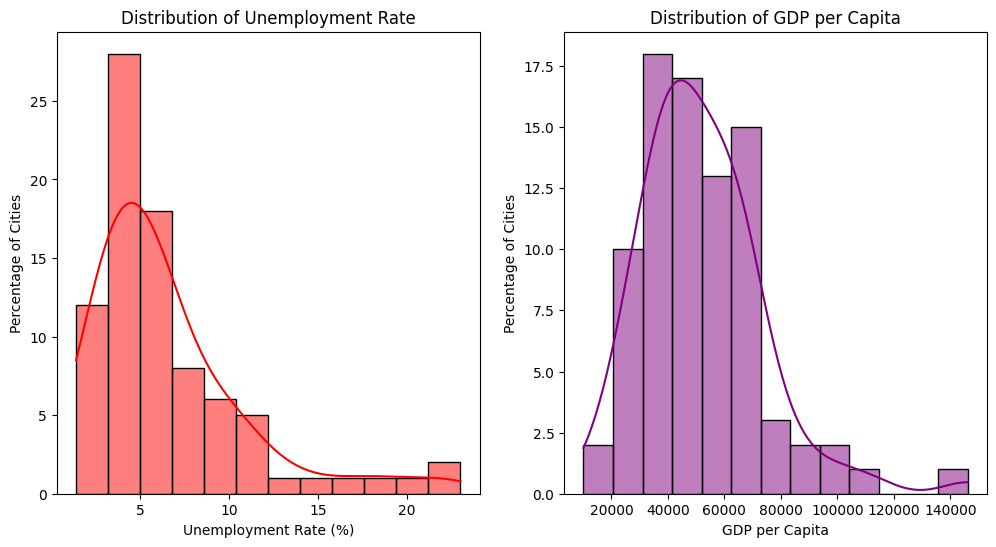

In [15]:
plt.figure(figsize=(12,6))
# Subplot Unemployment Rate Distribution 
plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
sns.histplot(city_data['Unemployment Rate'], kde = True, color = 'red')
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Percentage of Cities')

# Subplot for GDP per Capita Distribution 
plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
sns.histplot(city_data['GDP per Capita'], kde = True, color = 'purple')
plt.title('Distribution of GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Percentage of Cities')

plt.show()

From the histograms we can see that both of them are right skewed, while <u>most cities have a low unemployment rate</u>, below 10%, there are still some cities with a quite high unemployment rate (15-20%). Most cities have a <u>low or medium GDP per capita</u> in the 20k to 70k range, with very few cities having a very high GDP per capita above 100k. This shows that most cities are moderately wealthy, with only a few being extremely wealthy and a couple of other cities that are not so wealthy.

In [16]:
fig1 = px.scatter(city_data, x = 'GDP per Capita', y = 'Unemployment Rate', title='Relationship between GDP per Capita and Unemployment Rate', labels={'GDP per Capita':'GDP per Capita', 'Unemployment Rate':'Unemployment Rate (%)'}, hover_name='City', hover_data=['Country'])
fig1.show()

**Economic Insight: The GDP-Employment Correlation**

The scatter plot illustrates a clear **inverse relationship** between GDP per Capita and Unemployment Rate . As GDP per Capita increases, we observe a consistent downward trend in unemployment rates, reinforcing the idea that high-output urban economies provide more robust job security.

**Key Patterns Identified:**
- **The European Core:** A high density of cities is clustered between **€30,000 and €70,000 GDP**, with unemployment staying below **10%**.This cluster represents the majority of European cities, reflecting that in wealthier cities there are, generally, more job opportunities and hence a lower unemployment rate. 
- **The Bulgarian Exception:** An interesting outlier is **Bulgaria (Sofia)**. Despite having a significantly lower GDP (~€10,000), it maintains a remarkably low unemployment rate (4.6%). This suggests that its labor market is highly efficient or driven by specific local economic structures that don't depend solely on high-value GDP metrics.

**Strategic Implication:** This visualization proves that while wealth (GDP) is a strong predictor of job availability, it is not the only factor. For a person relocating, cities like those in Bulgaria might offer surprisingly high job security despite lower national wealth.

### **4.6. Salary vs Cost of Living Analysis**
**Question number 4 b) in the guidelines**

To better understand economic well-being and quality of life across European cities, we calculate a new variable called Spendable Income, defined as:  
- ``Spendable Income`` = ``Average Monthly Salary`` − ``Average Cost of Living``  

This metric estimates how much disposable income a typical resident retains after covering basic expenses, offering a clearer view of affordability and purchasing power across cities.

 Top 5 Cities with the Best Relationship between Salary and Cost of Living:


,City,Country,Spendable Income
0,Basel,Switzerland,2127
1,Tampere,Finland,1900
2,Helsinki,Finland,1850
3,Zurich,Switzerland,1774
4,Geneva,Switzerland,1531



 Bottom 5 Countries with the Worst Average Relationship:


,Country,Spendable Income
21,Portugal,-207.500000
11,Greece,-125.000000
23,Slovak Republic,-50.000000
28,Turkiye,-25.000000
20,Poland,-16.666667



Summary:
The 5 countries with the worst salary-to-cost relationship are: Portugal, Greece, Slovak Republic, Turkiye, Poland.
The top 5 cities with the best relationship are: Basel, Tampere, Helsinki, Zurich, Geneva.



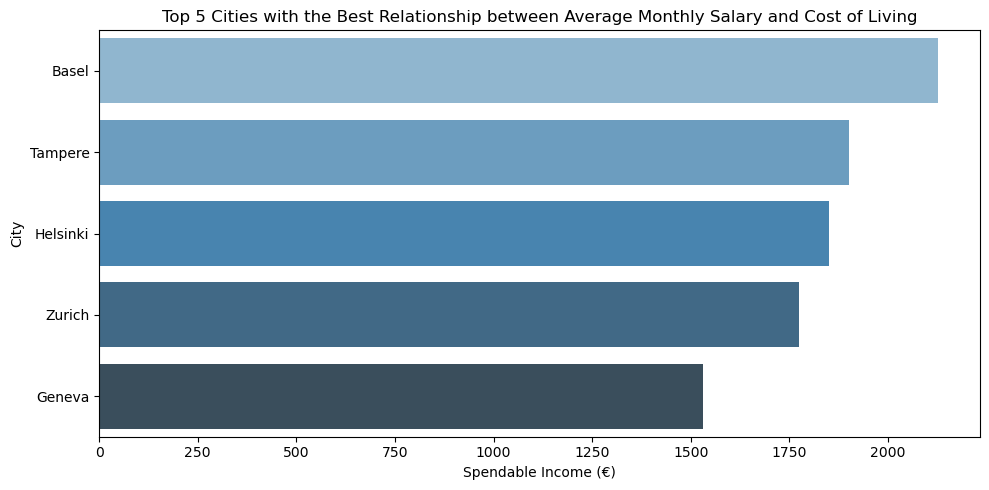

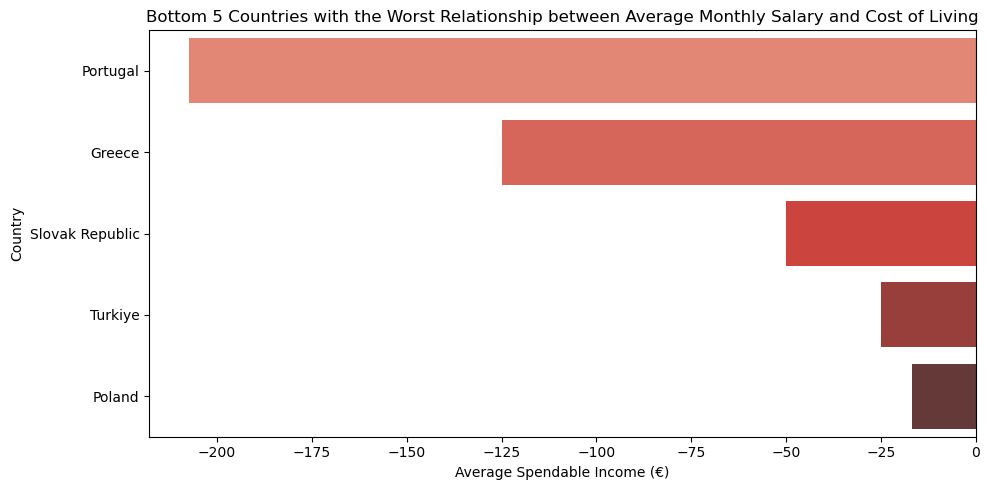

In [27]:
# Calculate Spendable Income (Salary - Cost of Living)
city_data['Spendable Income'] = city_data['Average Monthly Salary'] - city_data['Average Cost of Living']

# Top 5 cities with highest Spendable Income
top5_cities_diff = (
    city_data.nlargest(5, 'Spendable Income')[['City', 'Country', 'Spendable Income']]
    .reset_index(drop=True)
)
top5_cities_list = top5_cities_diff['City'].tolist()

# Bottom 5 countries with lowest average Spendable Income
bot5_country_avg_diff = (
    city_data.groupby('Country', as_index=False)['Spendable Income']
    .mean()
    .sort_values(by='Spendable Income', ascending=True)
    .head(5)
)
bot5_countries_list = bot5_country_avg_diff['Country'].tolist()

# Text summary of findings
print(" Top 5 Cities with the Best Relationship between Salary and Cost of Living:")
display(top5_cities_diff)

print("\n Bottom 5 Countries with the Worst Average Relationship:")
display(bot5_country_avg_diff)

print(f"\nSummary:\nThe 5 countries with the worst salary-to-cost relationship are: {', '.join(bot5_countries_list)}.")
print(f"The top 5 cities with the best relationship are: {', '.join(top5_cities_list)}.\n")

# Visualization: Top 5 Cities
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top5_cities_diff,
    x='Spendable Income',
    y='City',
    hue='City',          # Add hue for coloring
    palette='Blues_d',
    legend=False         # Hide redundant legend
)
plt.title('Top 5 Cities with the Best Relationship between Average Monthly Salary and Cost of Living')
plt.xlabel('Spendable Income (€)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

# Visualization: Bottom 5 Countries
plt.figure(figsize=(10, 5))
sns.barplot(
    data=bot5_country_avg_diff,
    x='Spendable Income',
    y='Country',
    hue='Country',       # Add hue for coloring
    palette='Reds_d',
    legend=False         # Hide redundant legend
)
plt.title('Bottom 5 Countries with the Worst Relationship between Average Monthly Salary and Cost of Living')
plt.xlabel('Average Spendable Income (€)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### **Top 5 Cities**
The first bar chart highlights the top five cities where the average salary most strongly exceeds the cost of living, meaning residents there retain the most disposable income. 

These cities represent the most financially comfortable locations in the dataset, offering better affordability and purchasing power.
Such cities are often characterized by strong job markets, high wages, and manageable living costs.  
One example is Basel that has largest difference between the ``Average Monthly Salary`` and ``Average Cost of Living``, registing a high value, 2127€.

High spendable income suggests that citizens in these cities enjoy a higher quality of life, with more room for savings, leisure, and personal investment.

##### **Bottom 5 Countries**
The second chart shows the five countries with the smallest average difference between salary and cost of living.
In these locations, living expenses consume most of the average salary, leaving residents with limited disposable income.

This pattern often reflects high living costs relative to wages, which can affect affordability and savings capacity.
It emphasizes how economic conditions differ significantly across Europe, even within developed regions, cost–income balance varies sharply.
Portugal have an aproximated value of negative 210€, which is the worst value of the bottom 5 countries

Countries appearing at the bottom may face challenges such as **slower wage growth, higher rent, or elevated prices for essentials**, all of which reduce purchasing power.

### **4.7. Ideal City Criteria**
**Question number 4 c) in the guidelines**

The goal here is to identify the best European city for someone that is looking for:  
- An ``Average Monthly Salary`` above €2000
- An ``Average Cost of Living`` below or equal to €1600
- The lowest possible unemployment rate  

By applying these filters, we identify which cities offer the best balance between income, expenses, and job stability, providing valuable insights for the type of individuals that we described, seeking strong economic and lifestyle opportunities.


Top 10 Cities Meeting the Conditions (Sorted by Spendable Income):


,City,Country,Average Monthly Salary,Average Cost of Living,Spendable Income,Unemployment Rate
36,Tampere,Finland,3500,1600,1900,6.6
23,Dresden,Germany,3050,1530,1520,3.8
4,Ghent,Belgium,2400,1200,1200,6.2
22,Leipzig,Germany,2800,1600,1200,4.3
31,Seville,Spain,2300,1150,1150,21.6
30,Valencia,Spain,2400,1300,1100,13.7
39,Toulouse,France,2600,1600,1000,8.5
32,Malaga,Spain,2200,1400,800,17.7
28,Madrid,Spain,2271,1589,682,10.8



Top 10 Cities with Lowest Unemployment Among the Qualified Ones:


,City,Country,Average Monthly Salary,Average Cost of Living,Spendable Income,Unemployment Rate
23,Dresden,Germany,3050,1530,1520,3.8
22,Leipzig,Germany,2800,1600,1200,4.3
4,Ghent,Belgium,2400,1200,1200,6.2
36,Tampere,Finland,3500,1600,1900,6.6
39,Toulouse,France,2600,1600,1000,8.5
28,Madrid,Spain,2271,1589,682,10.8
30,Valencia,Spain,2400,1300,1100,13.7
32,Malaga,Spain,2200,1400,800,17.7
31,Seville,Spain,2300,1150,1150,21.6


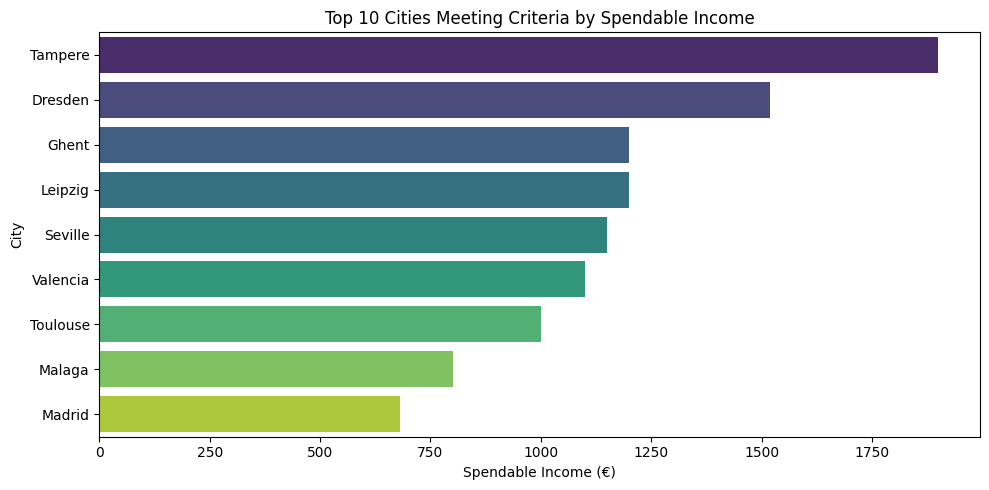

In [18]:
# Filter cities meeting the required conditions
qualified_cities = city_data[
    (city_data['Average Monthly Salary'] > 2000) &  # Salary above €2000
    (city_data['Average Cost of Living'] <= 1600)   # Cost of living below or equal to €1600
].copy()

# Sort and inspect the top options
print("Top 10 Cities Meeting the Conditions (Sorted by Spendable Income):")
display(
    qualified_cities.sort_values(by='Spendable Income', ascending=False)[
        ['City', 'Country', 'Average Monthly Salary', 'Average Cost of Living', 'Spendable Income', 'Unemployment Rate']
    ].head(10)
)

print("\nTop 10 Cities with Lowest Unemployment Among the Qualified Ones:")
display(
    qualified_cities.sort_values(by='Unemployment Rate', ascending=True)[
        ['City', 'Country', 'Average Monthly Salary', 'Average Cost of Living', 'Spendable Income', 'Unemployment Rate']
    ].head(10)
)

# Spendable Income of Qualified Cities
plt.figure(figsize=(10, 5))
sns.barplot(
    data=qualified_cities.sort_values(by='Spendable Income', ascending=False).head(10),
    x='Spendable Income',
    y='City',
    hue='City',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Cities Meeting Criteria by Spendable Income')
plt.xlabel('Spendable Income (€)')
plt.ylabel('City')
plt.tight_layout()
plt.show()


The dataset was filtered to include only cities where the ``Average Monthly Salary`` exceeds €2000 and the ``Average Cost of Living`` is below or equal to €1600.  
These criteria ensure that only economically favorable cities remain for evaluation.  
Among these cities, we examine two perspectives:  
- Those with the highest ``Spendable Income``, where residents retain more money after living expenses
- Those with the lowest ``Unemployment Rate``, representing stronger job stability  

This two-step view allows us to identify both financially rewarding and secure cities before selecting the overall best option.

Now we'll start from the ``qualified_cities`` variable that we created and sort it by both ``Unemployment Rate`` and ``Spendable Income`` so we get the best overall city that achieves all of the conditions set by these individuals

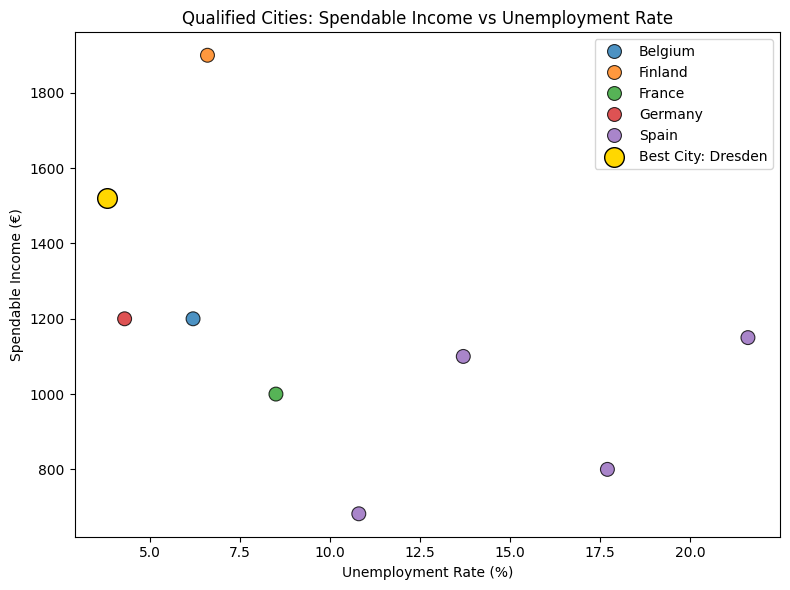


 Best Overall City Recommendation 
City: Dresden, Germany
- Average Monthly Salary: €3050.00
- Average Cost of Living: €1530.00
- Spendable Income: €1520.00
- Unemployment Rate: 3.8%

 This city offers the best balance between high income, affordable living costs, and low unemployment among all options.


In [19]:
# Select the best overall city
# Prioritize lowest unemployment rate, then highest spendable income
best_city = (
    qualified_cities
    .sort_values(by=['Unemployment Rate', 'Spendable Income'], ascending=[True, False])
    .iloc[0]
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=qualified_cities,
    x='Unemployment Rate',
    y='Spendable Income',
    hue='Country',
    s=100,
    alpha=0.8,
    edgecolor='black'
)

# Highlight the best city
plt.scatter(
    best_city['Unemployment Rate'],
    best_city['Spendable Income'],
    color='gold',
    s=200,
    edgecolor='black',
    label=f"Best City: {best_city['City']}"
)

# Titles and labels
plt.title('Qualified Cities: Spendable Income vs Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Spendable Income (€)')
plt.legend()
plt.tight_layout()
plt.show()


# Present results
print("\n Best Overall City Recommendation ")
print(f"City: {best_city['City']}, {best_city['Country']}")
print(f"- Average Monthly Salary: €{best_city['Average Monthly Salary']:.2f}")
print(f"- Average Cost of Living: €{best_city['Average Cost of Living']:.2f}")
print(f"- Spendable Income: €{best_city['Spendable Income']:.2f}")
print(f"- Unemployment Rate: {best_city['Unemployment Rate']:.1f}%")
print("\n This city offers the best balance between high income, affordable living costs, and low unemployment among all options.")



The selected city achieves the best overall balance between salary, cost of living, and unemployment rate.  
It provides strong earning potential, affordable expenses, and a favorable job market, making it the ideal destination for someone seeking both economic stability and quality of life.  
This analysis demonstrates how combining multiple socioeconomic indicators can produce a more meaningful ranking than relying on salary or cost alone.  


### **4.8. Additional Insights**
**Question number 5 in the guidelines**

In this section, we explore some additional information to deepen our understanding of European cities and find out which would be the best choice for someone trying to find a place to live in Europe.

### **4.8.1. Cost of Living vs Population Density**

In this part we analyze the distribution of ``Cost of Living`` across ``Population Density``, looking for a relationship between those two.

In [20]:
fig2 = px.scatter(city_data, x='Population Density', y='Average Cost of Living', title ='Cost of Living vs Population Density', labels={'Population Density':'Population Density (people per sq km)', 'Average Cost of Living':'Average Cost of Living (€)'}, hover_name='City', hover_data=['Country'])
fig2.show()

We can see there is a general trend where cities with higher population density also experience higher costs of living.  
This supports the idea that densely populated urban centers tend to have more expensive housing and services.

### **4.8.2. Salary vs Unemployment Rate**

We also thought we should find try to find out the relationship between ``Average Monthy Salary`` and ``Unemployment Rate``, or if there even is a relationship.

In [21]:
fig3 = px.scatter(city_data, x='Average Monthly Salary', y='Unemployment Rate', title='Average Monthly Salary vs Unemployment Rate', labels={'Average Monthly Salary':'Average Monthly Salary(€)', 'Unemployment Rate':'Unemployment Rate (%)'}, hover_name='City', hover_data=['Country'])
fig3.show()

Cities with higher salaries generally have lower unemployment rates.  
This suggests that stronger economies not only pay better but also provide more job opportunities.

### **4.8.3. Youth Dependency Ratio by Country**

Now we will look into the ``Youth Dependency Ratio`` for each ``Country`` to see which ones have the youngest populations as that alone can give us a bit of a future perspective for them.

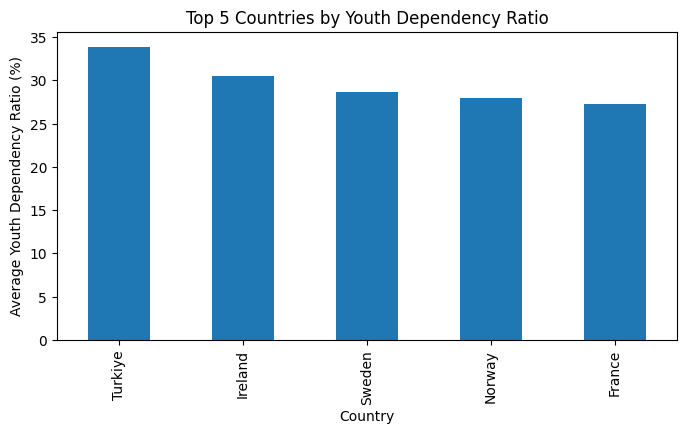

In [22]:
avg_youth = city_data.groupby('Country')['Youth Dependency Ratio'].mean().sort_values(ascending=False).head(5)
avg_youth.plot(kind='bar', figsize=(8,4))
plt.title('Top 5 Countries by Youth Dependency Ratio')
plt.ylabel('Average Youth Dependency Ratio (%)')
plt.show()

These 5 countries have relatively younger populations when compared to the rest, which could influence future labor market growth and education needs.  
This indicator is valuable for understanding demographic trends and long-term economic potential.

### **4.8.4. True Personal Wealth vs National Wealth: GDP vs Spendable Income**

We can also analyze the relatioship between ``GDP per Capita``, which should represents a wealthy country or city, and the ``Spendable Income``, a feature we created to be able to analyze personal financial freedom. Looking into this relationship can show us if living in a wealthy city actually means having a better lifestyle and more money that you can actually use freely.

In [23]:
fig4 = px.scatter(city_data, x = 'GDP per Capita', y = 'Spendable Income', title='GDP vs Personal Wealth', labels= {'GDP per Capita':'GDP per Capita', 'Spendable Income': 'Spendable Income'}, hover_name='City', hover_data= ['Country']) # creating the scatter plot as it's the most suitable to show a relationship between 2 numerical variables
fig4.show()

From the scatter plot we can see that there is a positive correlation between ``GDP per Capita`` and ``Spendable Income``, which makes sense as wealthier cities/countries tend to have higher salaries and affordable living costs, leading to more financial freedom for their residents. However, there are some outliers where cities with high ``GDP per Capita`` have relatively low ``Spendable Income``, indicating that high national wealth does not always translate to personal wealth for individuals living in those cities.

### **4.8.5. Climate Comfort: Strong Heat Stress Ratio**

This is more of a quality of life statistic, by simply analyzing the amount of ``Days of very strong heat stress``, which is the only climate metric that we have in the dataset.

We can assume that the cities with a lot of days with very strong heat stress are not very appealing to most people, while the ones with lower or medium  amounts of days with strong heat stress throughout the year, should be the most comfortable to live in for most people.

In [24]:
# Heat Stress Analysis
print('Cities with the least amount of days with very strong heat:')
print(city_data.sort_values(by='Days of very strong heat stress')[['City', 'Country', 'Days of very strong heat stress']].head(10))

print('\nCities with the most amount of days with very strong heat stress:')
print(city_data.sort_values(by='Days of very strong heat stress', ascending=False)[['City', 'Country', 'Days of very strong heat stress']].head(10))

# Graphical representation
plot_heat_stress = city_data[city_data['Days of very strong heat stress'] > 0]
plot_heat_stress.sort_values(by='Days of very strong heat stress', ascending=False, inplace=True)

# Iteractive Bar plot
fig5 = px.bar(plot_heat_stress, x = 'City', y= 'Days of very strong heat stress', title='Climate Comfort: Days of Very Strong Heat Stress per Year', labels={'City':'City', 'Days of very strong heat stress':'Days of Very Strong Heat Stress per Year'}, hover_name='City', hover_data=['Country'])
fig5.show()

Cities with the least amount of days with very strong heat:
          City   Country  Days of very strong heat stress
1     Salzburg   Austria                                0
5       Bruges   Belgium                                0
7      Dobrich  Bulgaria                                0
6        Sofia  Bulgaria                                0
14     Ostrava   Czechia                                0
26  Copenhagen   Denmark                                0
27      Odense   Denmark                                0
12    Limassol    Cyprus                                0
23     Dresden   Germany                                0
36     Tampere   Finland                                0

Cities with the most amount of days with very strong heat stress:
            City  Country  Days of very strong heat stress
85         Adana  Turkiye                               59
31       Seville    Spain                               53
11       Nicosia   Cyprus                               45

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10056\2781934015.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



From the barplot we can take away the cities that have the most heat stress throughout the year and based on that choose where to live aligning this information with our preferences.

### **5. Exporting the Clean Dataset**

In [25]:
city_data.to_csv('city_data_cleaned.csv', index=False) # Exporting the clean dataset to a new CSV file